In [81]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from functools import reduce

In [113]:
co2_case = 'max_co2_injection'
cases = ['noemissionscap', '30pct', '60pct', '80pct']
flow_dfs = {}

for case in cases:
    flows = pd.read_csv('results/' + co2_case + '/' + case + '/results/flows.csv')
    flow_dfs[case] = flows

FileNotFoundError: [Errno 2] No such file or directory: 'results/max_co2_injection/30pct/results/flows.csv'

In [ ]:
def get_flow_sums_by_tech(
    flow_df,
    include_keywords=None,     # list of substrings to keep column names
    drop_techs=None            # list of tech names to drop
):
    """
    Build a Region × Technology CO₂ emissions table (Region = rows).
    """

    # --- 1. Select columns ---
    if include_keywords is not None:
        co2_cols = [
            c for c in flow_df.columns
            if any(kw in c for kw in include_keywords)
        ]
    else:
        co2_cols = [
            c for c in flow_df.columns
            if "co2" in c.lower() and "edge" in c.lower()
        ]

    # --- Region sort ---
    def region_sort_key(name):
        match = re.search(r"Region(\d+)", name)
        return int(match.group(1)) if match else 999

    co2_cols = sorted(co2_cols, key=region_sort_key)

    # --- 2. Sum flows across time ---
    co2_sums = flow_df[co2_cols].sum()

    # --- 3. Extract Region and Technology names in one pass ---
    # Handles both Region-first columns (e.g. Region1Beijing_meacement_co2_edge)
    # and tech-first columns (e.g. aluminum_smelting_Region1Beijing_co2_edge).
    full_pattern = re.compile(r"^(.*?)Region\d+([A-Za-z]+)_(.*)")

    rows = []
    for col, val in co2_sums.items():
        m = full_pattern.match(col)
        if m:
            prefix = m.group(1).rstrip("_")   # e.g. "aluminum_smelting" or ""
            region = m.group(2)                # e.g. "Beijing"
            suffix = m.group(3)               # e.g. "co2_edge"
            tech = (prefix + "_" + suffix) if prefix else suffix
            rows.append({"Region": region, "Technology": tech, "Value": val})

    df = pd.DataFrame(rows)

    co2_by_region_tech = df.pivot_table(
        index="Region",
        columns="Technology",
        values="Value",
        aggfunc="sum"
    )

    co2_by_region_tech = co2_by_region_tech[
        sorted(co2_by_region_tech.columns, key=lambda x: x.lower())
    ]

    # --- 4. Drop unwanted technologies ---
    if drop_techs is not None:
        existing = [t for t in drop_techs if t in co2_by_region_tech.columns]
        co2_by_region_tech = co2_by_region_tech.drop(columns=existing)

    return co2_by_region_tech


In [114]:
co2_by_region_tech_dict = {}
co2_all_china_by_tech = pd.DataFrame()

for case in cases:
    co2_by_region_tech = get_flow_sums_by_tech(
    flow_dfs[case],
    include_keywords=["co2_edge", "co2_emissions_edge"],
    drop_techs=["nuclear_co2_edge", "oxyfuelcement_co2_emissions_edge"]
)   
    co2_by_region_tech_dict[case] = co2_by_region_tech
    co2_all_china_by_tech[case] = co2_by_region_tech.sum()

KeyError: '30pct'

In [87]:
co2_all_china_by_tech

,noemissionscap,30pct,60pct,80pct
Technology,,,,
alumina_plant_co2_edge,3.501063e-17,7.774430e+01,1.048806e+02,3.846306e+02
aluminum_smelting_co2_edge,5.485255e-17,1.253417e+02,1.670981e+02,6.183851e+02
bfbof_co2_edge,5.252278e+07,5.252270e+07,2.460907e+07,1.144487e+01
bfbofccs_co2_edge,3.639929e-20,9.961481e-02,6.592338e-02,8.027969e+00
bfbofccs_retrofit_co2_edge,1.050907e-19,2.858871e-01,1.224692e-01,9.486976e+00
coal_co2_edge,2.692651e+08,1.020633e+08,6.269177e+05,7.802653e+03
drieaf_co2_edge,2.369743e-18,2.269357e+00,5.182247e+05,1.206419e+06
drieaf_retrofit_co2_edge,4.650528e-20,7.841556e-01,3.116884e+05,3.116874e+05
gasdri_co2_edge,2.714893e-17,4.325577e+00,2.746875e+00,8.131681e+00


# Plot CO2 Emissions by Region and Tech

In [88]:
scenario_map = {
    "noemissionscap": "No Emissions Policy",
    "30pct": "30% Emissions Reduction",
    "60pct": "60% Emissions Reduction",
    "80pct": "80% Emissions Reduction"
}


In [89]:
# Make Name Map
tech_name_map = {
    # Cement
    "oxyfuelcement_retrofit_co2_emissions_edge": "Oxyfuel Cement Retrofit",
    "meacement_co2_emissions_edge": "MEA Cement Retrofit",
    "tradcement_co2_emissions_edge": "Traditional Cement",

    # Steel (BF-BOF and Scrap EAF)
    "bfbof_co2_edge": "BF-BOF",
    "bfbofccs_co2_edge": "BF-BOF-CCS",
    "bfbofccs_retrofit_co2_edge": "BF-BOF-CCS Retrofit",
    "scrapeaf56_co2_edge": "Scrap EAF 56%",
    "scrapeaf100_co2_edge": "Scrap EAF 100%",
    "scrapeaf100_retrofit_co2_edge": "Scrap EAF 100% Retrofit",

    # Steel (DRI Routes)
    "drieaf_co2_edge": "DRI-EAF",
    "drieaf_retrofit_co2_edge": "DRI-EAF Retrofit",
    "gasdri_co2_edge": "Gas DRI",
    "gasdriccs_co2_edge": "Gas DRI with CCS",
    "h2dri_co2_edge": "H2 DRI",

    # Aluminum
    "alumina_plant_co2_edge": "Alumina Plant",
    "aluminum_smelting_co2_edge": "Aluminum Smelting",

    # Power & Energy
    "coal_co2_edge": "Coal Power",
    "naturalgas_power_co2_edge": "Natural Gas Power",
}


In [90]:
custom_color_map = {
    "Oxyfuel Cement Retrofit": "#ff9d9a",
    "MEA Cement Retrofit": "#f28e9b",
    "Traditional Cement": "#e15759",

    # Steel - Primary & Scrap
    "BF-BOF": "#1f77b4",
    "BF-BOF-CCS": "#0ee3ff",
    "BF-BOF-CCS Retrofit": "#aec7e8",
    "Scrap EAF 56%": "#38a938",
    "Scrap EAF 100%": "#6acaa2",
    "Scrap EAF 100% Retrofit": "#98df8a",

    # Steel - DRI Routes
    "DRI-EAF": "#9467bd",
    "DRI-EAF Retrofit": "#c5b0d5",
    "Gas DRI": "#8c564b",
    "Gas DRI with CCS": "#e377c2",
    "H2 DRI": "#17becf",

    # Aluminum
    "Alumina Plant": "#d4c5a9",
    "Aluminum Refining": "#c9a96e",
    "Aluminum Smelting": "#bbbbb2",

    # Power
    "Natural Gas Power": "#eb7a23",
    "Coal Power": "#4a5568",

    "Hydropower": "#3e6496",
    "Solar PV (Centralized)":"#fbb04e",
    "Solar PV (Distributed)": "#f1ce63",
    "Wind (Offshore)": "#638fbb",
    "Wind (Onshore)": "#90bfe2",
    "Battery Storage": "#9f6490",
    "Nuclear": "#3c8782",
    "Pumped Hydro Storage": "#75afa7"
}


In [91]:
import plotly.express as px
import pandas as pd

def plot_stacked_bar(
    df,
    scenario_map=None,      # maps scenario/column names to pretty names
    name_map=None,          # maps technology names (index) to pretty names
    color_map=None,         # maps pretty tech names --> colors
    title_name="none",
    xaxis_name="none",
    yaxis_name="none",
    width=1200,
    height=600,
):
    """
    Create a stacked bar plot where:
      - each COLUMN of df becomes a bar (scenario)
      - each ROW/index becomes a stacked segment (technology)

    New features:
      • scenario_map: dict mapping df column → label
      • title_name, xaxis_name, yaxis_name: optional labels (default = "none")
    """

    # --- Apply scenario_map to rename incoming bar labels ---
    if scenario_map:
        df = df.rename(index=scenario_map)

    # Transpose so that each scenario becomes one bar
    df = df.T

    # Ensure the index has a name
    if not df.index.name:
        df = df.copy()
        df.index.name = "Category"

    row_label = df.index.name

    # Convert to long format
    df_long = df.reset_index().melt(
        id_vars=row_label,
        var_name="Scenario",
        value_name="Value"
    )

    # --- Apply name_map to legend entries (index entries) ---
    display_col = row_label + "_Display"

    if name_map:
        df_long[display_col] = df_long[row_label].map(lambda x: name_map.get(x, x))
    else:
        df_long[display_col] = df_long[row_label]

    # --- If color_map is provided, remap using the display names ---
    if color_map and name_map:
        color_map = {name_map.get(k, k): v for k, v in color_map.items()}

    fig = px.bar(
        df_long,
        x="Scenario",
        y="Value",
        color=display_col,
        title=None if title_name == "none" else title_name,
        labels={
            "Scenario": xaxis_name if xaxis_name != "none" else "Scenario",
            "Value": yaxis_name if yaxis_name != "none" else "Value",
            display_col: row_label
        },
        color_discrete_map=color_map,
    )

    fig.update_layout(
        barmode="stack",
        template="plotly_white",
        width=width,
        height=height,
        margin=dict(l=60, r=60, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)
    return fig


In [92]:
plot_stacked_bar(
    df = co2_all_china_by_tech.T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name="Emissions by Source for 4 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National CO2 Emissions (Tonnes)",
    width=700)

In [93]:
from plotly.subplots import make_subplots

def plot_scenario_subplots(
    co2_dict,
    scenario_map,            # dict: scenario_key -> display label
    name_map=None,
    color_map=None,
    ymax=30e6,
    ncols=None,
    title_prefix="",
    xaxis_name="none",
    yaxis_name="none",
    width=2500
):
    keys = list(co2_dict.keys())
    n = len(keys)

    if ncols is None:
        ncols = n

    # ---- Create subplot grid ----
    fig = make_subplots(
        rows=1,
        cols=ncols,
        subplot_titles=[f"{title_prefix}{scenario_map[k]}" for k in keys],
        horizontal_spacing=0.05,
    )

    # ---- Loop through scenarios ----
    for col_idx, key in enumerate(keys, start=1):
        df = co2_dict[key]

        # Build stacked bar chart WITHOUT axis titles (we add them manually)
        subfig = plot_stacked_bar(
            df,
            scenario_map=scenario_map,
            name_map=name_map,
            color_map=color_map,
            title_name="none",
            xaxis_name="none",
            yaxis_name="none"
        )

        # Add each trace into its subplot
        for trace in subfig.data:
            trace.showlegend = (col_idx == 1)   # only show legend in first
            fig.add_trace(trace, row=1, col=col_idx)

        # Set y-range
        fig.update_yaxes(range=[0, ymax], row=1, col=col_idx)

    # ---- Add AXIS TITLES manually (important) ----
    # y-axis title only on the first subplot
    if yaxis_name != "none":
        fig.update_yaxes(title_text=yaxis_name, row=1, col=1)

    # x-axis titles on each subplot
    if xaxis_name != "none":
        for col_idx in range(1, ncols+1):
            fig.update_xaxes(title_text=xaxis_name, row=1, col=col_idx)

    # ---- Layout ----
    fig.update_layout(
        template="plotly_white",
        barmode="stack",
        height=650,
        width=width,
        legend_title="Category",
        margin=dict(l=40, r=40, t=80, b=80),
        legend=dict(traceorder="reversed")
    )

    fig.update_xaxes(tickangle=-45)

    return fig


In [94]:
co2_by_region_tech_dict['30pct']

Technology,alumina_plant_co2_edge,aluminum_smelting_co2_edge,bfbof_co2_edge,bfbofccs_co2_edge,bfbofccs_retrofit_co2_edge,coal_co2_edge,drieaf_co2_edge,drieaf_retrofit_co2_edge,gasdri_co2_edge,gasdriccs_co2_edge,h2dri_co2_edge,meacement_co2_emissions_edge,meacement_retrofit_co2_emissions_edge,naturalgas_power_co2_edge,oxyfuelcement_retrofit_co2_emissions_edge,R_oxyfuelcement_retrofit_co2_emissions_edge,scrapeaf100_co2_edge,scrapeaf100_retrofit_co2_edge,scrapeaf56_co2_edge,tradcement_co2_emissions_edge
Region,,,,,,,,,,,,,,,,,,,,
Anhui,0.009974,4.192046,1.864101e+06,0.003431,0.009820,5.549312e+06,0.023381,0.026298,0.143754,0.015158,0.0,0.0,0.288302,1.778069e+06,0.019226,NaN,0.007007,12679.284151,56.067182,3.397260e+06
Beijing,0.290903,4.084840,3.204730e+06,0.003436,0.010069,3.959246e+02,0.072284,0.026591,0.152823,0.018709,0.0,0.0,0.286672,1.913840e+06,0.013390,NaN,0.007872,9863.685752,42.131987,6.652183e+04
Chongqing,5.511492,4.179599,6.545763e+05,0.003439,0.009842,6.847265e+05,0.079175,0.027793,0.151917,0.016327,0.0,0.0,0.284765,1.660964e+06,0.019145,NaN,0.007892,2419.046880,12705.192427,1.538593e+06
Fujian,0.236504,4.030406,1.450540e+06,0.003490,0.010020,2.217565e+06,0.145889,0.036093,0.155254,0.014152,0.0,0.0,0.279861,2.120437e+06,0.019082,NaN,0.007641,25778.510764,273.828144,2.299365e+06
Gansu,3.594610,4.124683,5.745754e+05,0.003424,0.009818,2.534828e+06,0.047034,0.027934,0.149334,0.014970,0.0,0.0,0.285516,4.331701e+05,0.019036,NaN,0.007232,1870.765492,17262.134164,1.139754e+06
Guangdong,2.711024,4.113438,1.662862e+06,0.003497,0.010032,1.343351e+07,0.084607,0.029387,0.145592,0.013254,0.0,0.0,0.275948,4.601115e+06,0.018292,NaN,0.007190,915.697713,344617.482531,3.374758e+06
Guangxi,7.373007,4.314977,2.175695e+06,0.003489,0.010036,2.755310e+06,0.131786,0.064579,0.157369,0.014528,0.0,0.0,0.279474,1.517501e+06,0.019512,NaN,0.007368,1.284943,478795.069506,3.445776e+06
Guizhou,3.741331,4.074725,2.012520e+05,0.003447,0.009759,3.810311e+06,0.065872,0.030259,0.150794,0.016010,0.0,0.0,0.291919,3.866260e+05,0.009383,NaN,0.007548,1.277757,218947.561826,2.629664e+06
Hainan,2.333767,4.338865,NaN,NaN,NaN,3.342785e+05,NaN,NaN,NaN,NaN,NaN,0.0,0.199635,2.739117e+05,0.100124,NaN,NaN,NaN,NaN,5.945835e+05


In [95]:
plot_scenario_subplots(
    co2_by_region_tech_dict,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    ymax=30e6,
    xaxis_name='Province',
    yaxis_name='CO2 Emissions (Tonnes)',
    width=2000
)

In [96]:
flows = flow_dfs['noemissionscap']
co2_cols = [c for c in flows.columns if (c.endswith("co2_edge") or c.endswith("co2_emissions_edge"))]

region_groups = {}
for col in flows[co2_cols].columns:
    region = col.split("_")[0]   # e.g. Region1Beijing
    region_groups.setdefault(region, []).append(col)

# Now sum per region
region_sums = pd.DataFrame()

for region, cols in region_groups.items():
    region_sums[region] = flows[cols].sum(axis=1)

region_sums.sum().sort_values(ascending=False)


Region15Shandong        3.335708e+07
Region10Jiangsu         3.110393e+07
Region19Guangdong       2.907899e+07
Region3Hebei            2.901686e+07
Region5Innermongolia    2.275048e+07
Region12Anhui           2.116188e+07
Region4Shanxi           1.966473e+07
Region16Henan           1.816201e+07
Region11Zhejiang        1.763696e+07
Region31Xinjiang        1.484792e+07
Region20Guangxi         1.416554e+07
Region27Shaanxi         1.280877e+07
Region17Hubei           1.251197e+07
Region13Fujian          1.155880e+07
Region14Jiangxi         1.083602e+07
Region24Guizhou         1.010375e+07
Region18Hunan           9.950847e+06
Region6Liaoning         9.488881e+06
Region28Gansu           8.869232e+06
Region23Sichuan         8.255013e+06
Region30Ningxia         6.344836e+06
Region22Chongqing       5.902112e+06
Region9Shanghai         5.457034e+06
Region7Jilin            5.375413e+06
Region8Heilongjiang     5.240477e+06
Region25Yunnan          4.930176e+06
Region2Tianjin          4.464251e+06
R

# Plot Cement Capacity Decisions

In [97]:
# Load Capacity Data

cases = ["noemissionscap", "30pct", "60pct", "80pct"]
capacity_dfs = {}

for case in cases:
    capacity = pd.read_csv("results/" + co2_case + "/" + case + "/results/capacity.csv")
    capacity["region_name"] = (capacity["resource_id"].astype(str).str.extract(r"Region\d+([A-Za-z]+)", expand=False))
    capacity_dfs[case] = capacity


In [98]:
def get_capacity_by_sector(capacity_dfs, cases):
    """
    Extract capacity dataframes for electricity, cement, steel, and aluminum.

    Parameters
    ----------
    capacity_dfs : dict[str, pd.DataFrame]
        Dict of case name → raw capacity CSV DataFrame (with region_name column).
    cases : list[str]
        Cases to extract; must be keys in capacity_dfs.

    Returns
    -------
    elec_dict, cement_dict, steel_dict, aluminum_dict : dict[str, pd.DataFrame]
        Each dict is keyed by case name. Each DataFrame is indexed by region_name
        with display-name columns, ready to pass directly to plot_province_pies.
    """

    # ── Suffix-based extractor (cement / steel / aluminum) ──────────────────
    def _extract_by_suffix(df, suffix_to_display):
        tmp = df[["region_name", "resource_id", "capacity"]].copy()

        def match(rid):
            for suf, name in suffix_to_display.items():
                if str(rid).endswith(suf):
                    return name
            return None

        tmp["tech"] = tmp["resource_id"].map(match)
        tmp = tmp[tmp["tech"].notna()]
        result = (
            tmp.groupby(["region_name", "tech"], as_index=False)["capacity"].sum()
            .pivot(index="region_name", columns="tech", values="capacity")
            .fillna(0)
            .reindex(columns=list(suffix_to_display.values()))
        )
        result.columns.name = None
        return result

    # ── Sector definitions ───────────────────────────────────────────────────
    _elec_rename = {
        "coal":             "Coal Power",
        "Hydropower":       "Hydropower",
        "PV_Central":       "Solar PV (Centralized)",
        "PV_Distribution":  "Solar PV (Distributed)",
        "Wind_Offshore":    "Wind (Offshore)",
        "Wind_Onshore":     "Wind (Onshore)",
        "battery":          "Battery Storage",
        "naturalgas_power": "Natural Gas Power",
        "nuclear":          "Nuclear",
        "pumpedhydro":      "Pumped Hydro Storage",
    }
    _elec_techs = set(_elec_rename.keys())

    _cement_suffixes = {
        "_tradcement":             "Traditional Cement",
        "_oxyfuelcement_retrofit": "Oxyfuel Cement Retrofit",
        "_meacement":              "MEA Cement Retrofit",
    }

    _steel_suffixes = {
        "_bfbof":                  "BF-BOF",
        "_bfbofccs_retrofit":      "BF-BOF-CCS Retrofit",
        "_bfbofccs":               "BF-BOF-CCS",
        "_scrapeaf56":             "Scrap EAF 56%",
        "_scrapeaf100_retrofit":   "Scrap EAF 100% Retrofit",
        "_scrapeaf100":            "Scrap EAF 100%",
        "_drieaf_retrofit":        "DRI-EAF Retrofit",
        "_drieaf":                 "DRI-EAF",
    }

    # Aluminum resources use the format {tech}_Region{N}{Province},
    # so we match by prefix rather than suffix.
    _aluminum_prefixes = {
        "alumina_plant":     "Alumina Plant",
        "aluminum_refining": "Aluminum Refining",
        "aluminum_smelting": "Aluminum Smelting",
    }

    def _extract_by_prefix(df, prefix_to_display):
        tmp = df[["region_name", "resource_id", "capacity"]].copy()
        def match(rid):
            for pre, name in prefix_to_display.items():
                if str(rid).startswith(pre + "_Region"):
                    return name
            return None
        tmp["tech"] = tmp["resource_id"].map(match)
        tmp = tmp[tmp["tech"].notna()]
        if tmp.empty:
            return pd.DataFrame(columns=list(prefix_to_display.values()))
        result = (
            tmp.groupby(["region_name", "tech"], as_index=False)["capacity"].sum()
            .pivot(index="region_name", columns="tech", values="capacity")
            .fillna(0)
            .reindex(columns=list(prefix_to_display.values()))
        )
        result.columns.name = None
        return result

    # ── Build one df per case per sector ────────────────────────────────────
    elec_dict, cement_dict, steel_dict, aluminum_dict = {}, {}, {}, {}

    for case in cases:
        df = capacity_dfs[case]

        # Electricity
        df_e = df.copy()
        df_e["technology"] = df_e["resource_id"].str.split("_", n=1).str[1]
        df_e = df_e[df_e["technology"].isin(_elec_techs)]
        df_e = df_e[~df_e["component_id"].str.endswith("inflow_edge")]
        df_e = df_e[~df_e["component_id"].str.contains("storage", na=False)]
        elec_df = (
            df_e.pivot(index="region_name", columns="technology", values="capacity")
            .rename(columns=_elec_rename)
        )
        elec_df.columns.name = None
        elec_dict[case] = elec_df

        cement_dict[case]   = _extract_by_suffix(df, _cement_suffixes)
        steel_dict[case]    = _extract_by_suffix(df, _steel_suffixes)
        aluminum_dict[case] = _extract_by_prefix(df, _aluminum_prefixes)

    return elec_dict, cement_dict, steel_dict, aluminum_dict

In [99]:
def consolidate_capacity(sector_dict):
    """
    Consolidate a sector capacity dict into a single DataFrame.

    Parameters
    ----------
    sector_dict : dict[str, pd.DataFrame]
        Output from get_capacity_by_sector — keyed by case name, each value
        is a region × technology DataFrame.

    Returns
    -------
    pd.DataFrame
        Technology × case DataFrame (national totals), ready for plot_stacked_bar.
    """
    return pd.DataFrame(
        {case: df.sum() for case, df in sector_dict.items()}
    )


In [100]:
elec_df, cement_df, steel_df, aluminum_df = get_capacity_by_sector(capacity_dfs, cases)

In [101]:
plot_stacked_bar(
    consolidate_capacity(elec_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Electricity Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Steel Production Capacity (MW)",
    width=700
)

In [102]:
plot_stacked_bar(
    consolidate_capacity(steel_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Steel Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Steel Production Capacity (Tonnes Steel / Hour)",
    width=700
)

In [103]:
plot_stacked_bar(
    consolidate_capacity(cement_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Cement Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Cement Production Capacity (Tonnes Cement / Hour)",
    width=700
)

In [105]:
plot_stacked_bar(
    consolidate_capacity(aluminum_df).T,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    title_name = "Aluminum Capacity Decisions in 3 Emissions Scenarios",
    xaxis_name="Emissions Scenario",
    yaxis_name="National Aluminum Production Capacity (MW)",
    width=700
)

In [106]:
plot_scenario_subplots(
    steel_df,
    scenario_map=scenario_map,
    name_map=tech_name_map,
    color_map=custom_color_map,
    ymax = 15000,
    xaxis_name='Province',
    yaxis_name='Cement Production Capacity (Tonnes Cement / Day)',
    width=2000
)

# Pie Charts

In [107]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
import numpy as np
import pandas as pd

def plot_province_pies(
    gdf,
    data_df,
    province_col="NAME_1",
    categories=None,
    colors=None,
    pie_scale=1.0,
    figsize=(14,10),
    title="",
    legend_sizes=None,
    capacity_unit="MW"
):
    if categories is None:
        categories = list(data_df.columns)

    if colors is None:
        cmap = plt.cm.tab20
        colors = {cat: cmap(i) for i, cat in enumerate(categories)}

    # --- 1. PROJECT TO WEB-MERCATOR TO FIX DISTORTION ---
    gdf_proj = gdf.to_crs(epsg=3857)

    # Merge data — left join keeps all provinces on the map (NaN capacity → 0)
    gdf_proj = gdf_proj.merge(data_df, left_on=province_col, right_index=True, how="left")
    gdf_proj[categories] = gdf_proj[categories].fillna(0)

    # Compute projected centroids (in meters → circles stay circles)
    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    gdf_proj["cx"] = gdf_proj.centroid.x
    gdf_proj["cy"] = gdf_proj.centroid.y

    # Compute dynamic radii
    gdf_proj["total_value"] = gdf_proj[categories].sum(axis=1)
    max_total = gdf_proj["total_value"].max() or 1
    gdf_proj["radius"] = (gdf_proj["total_value"] / max_total) * pie_scale * 80_000
    # ^ 80 km radius for the largest pie — adjust scale if needed

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()

    # Draw pies
    for _, row in gdf_proj.iterrows():

        cx, cy, r = row["cx"], row["cy"], row["radius"]

        vals = row[categories].values.astype(float)
        total = vals.sum()
        if total == 0:
            continue

        angles = np.cumsum(vals) / total * 360
        prev_angle = 0

        for cat, angle in zip(categories, angles):
            wedge = Wedge(
                center=(cx, cy),
                r=r,
                theta1=prev_angle,
                theta2=angle,
                facecolor=colors[cat],
                edgecolor="none",
                alpha=1.0,
                zorder=1000
            )
            ax.add_patch(wedge)
            prev_angle = angle

    # Draw province boundaries underneath
    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="black", linewidth=0.7, zorder=0)
    gdf_proj.boundary.plot(ax=ax, linewidth=0.7, color="black", zorder=1)
    plt.rcParams['lines.antialiased'] = True

    # --- Size legend ---
    if legend_sizes is not None and len(legend_sizes) > 0:
        legend_radii = [(s / max_total) * pie_scale * 80_000 for s in legend_sizes]
        sizes_and_radii = sorted(zip(legend_sizes, legend_radii))  # ascending by size

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        plot_width  = xlim[1] - xlim[0]
        plot_height = ylim[1] - ylim[0]

        pad_x = plot_width  * 0.02
        pad_y = plot_height * 0.02
        max_r = max(legend_radii)
        legend_cx = xlim[0] + pad_x + max_r

        # Stack circles from bottom (largest) to top (smallest), bottom-edge aligned per circle
        y = ylim[0] + pad_y
        for size, radius in sizes_and_radii:
            cy_legend = y + radius
            circle = Circle(
                (legend_cx, cy_legend), radius,
                facecolor="white", edgecolor="#555555",
                linewidth=1.2, zorder=2000
            )
            ax.add_patch(circle)
            label = f"{size:,.0f} {capacity_unit}"
            ax.text(
                legend_cx + max_r + pad_x * 0.6,
                cy_legend,
                label,
                va="center", ha="left", fontsize=9, zorder=2001
            )
            y += radius * 2 + pad_y * 0.4

    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.show()


In [108]:
gdf = gpd.read_file("../gadm36_CHN_1.json")

# --- Fix province names if needed ---
rename_map = {
    "Nei Mongol": "Innermongolia",
    "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
}

gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

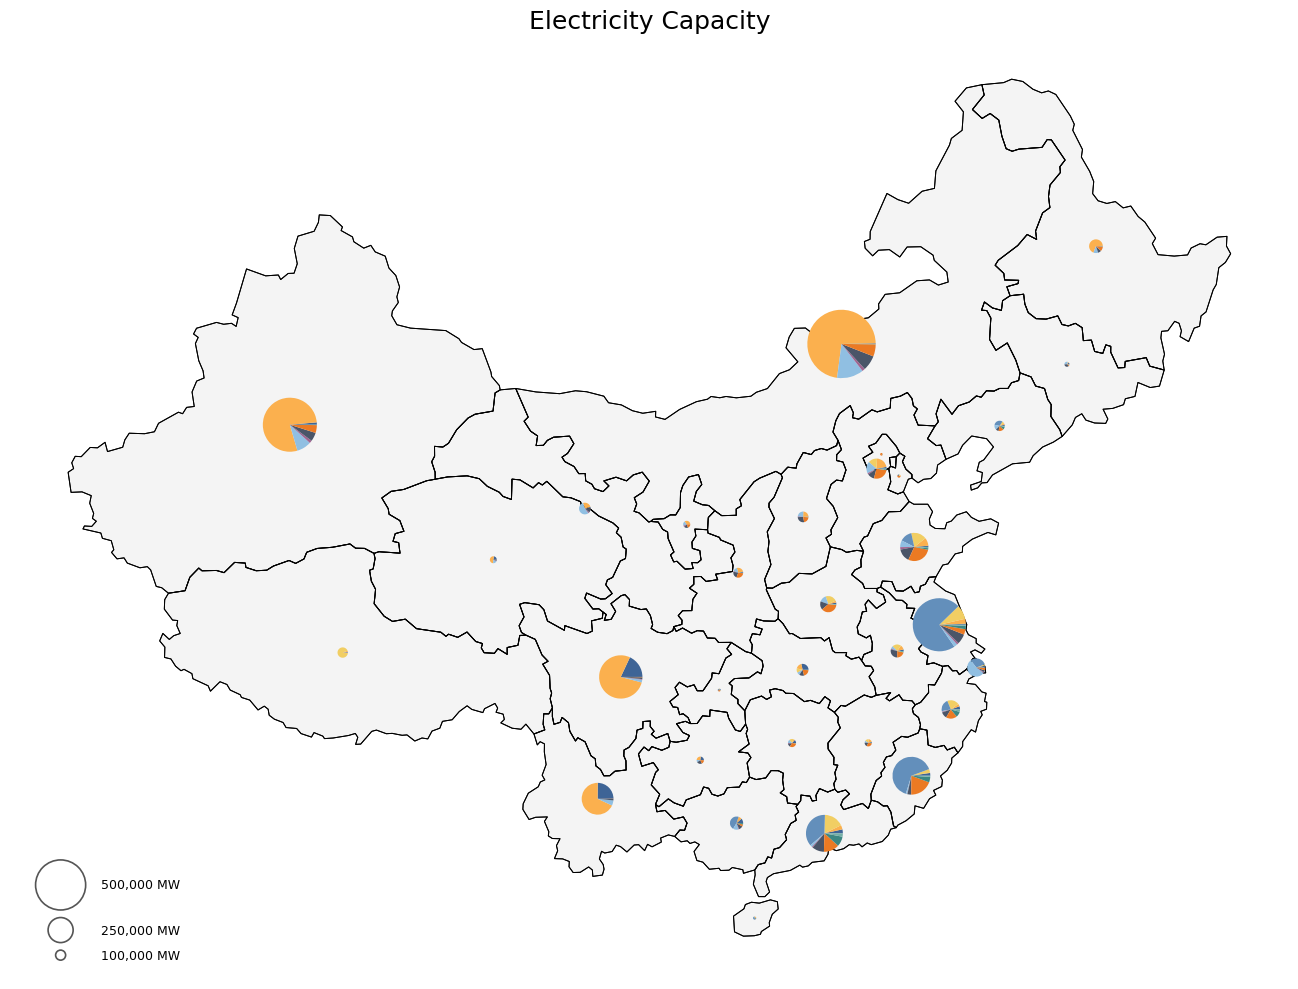

In [109]:
plot_province_pies(gdf, elec_df[case],
                   colors=custom_color_map,
                   pie_scale=2.5,
                   title="Electricity Capacity",
                   legend_sizes=[100_000, 250_000, 500_000],
                   capacity_unit="MW")



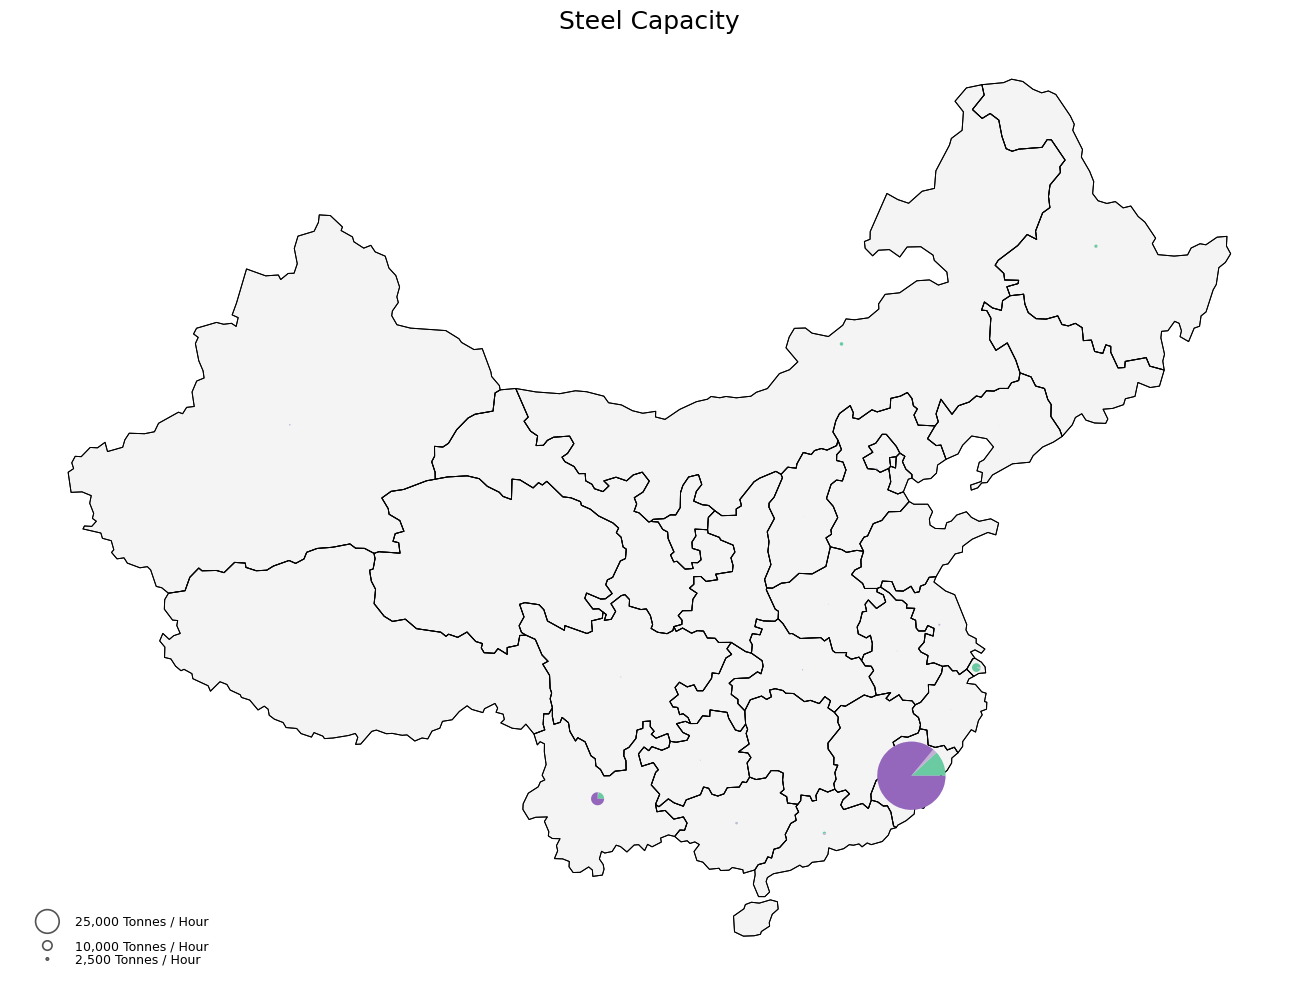

In [110]:
plot_province_pies(gdf, steel_df['80pct'],
                   colors=custom_color_map,
                   pie_scale=2.5,
                   title="Steel Capacity",
                   legend_sizes=[2_500, 10_000, 25_000],
                   capacity_unit="Tonnes / Hour")

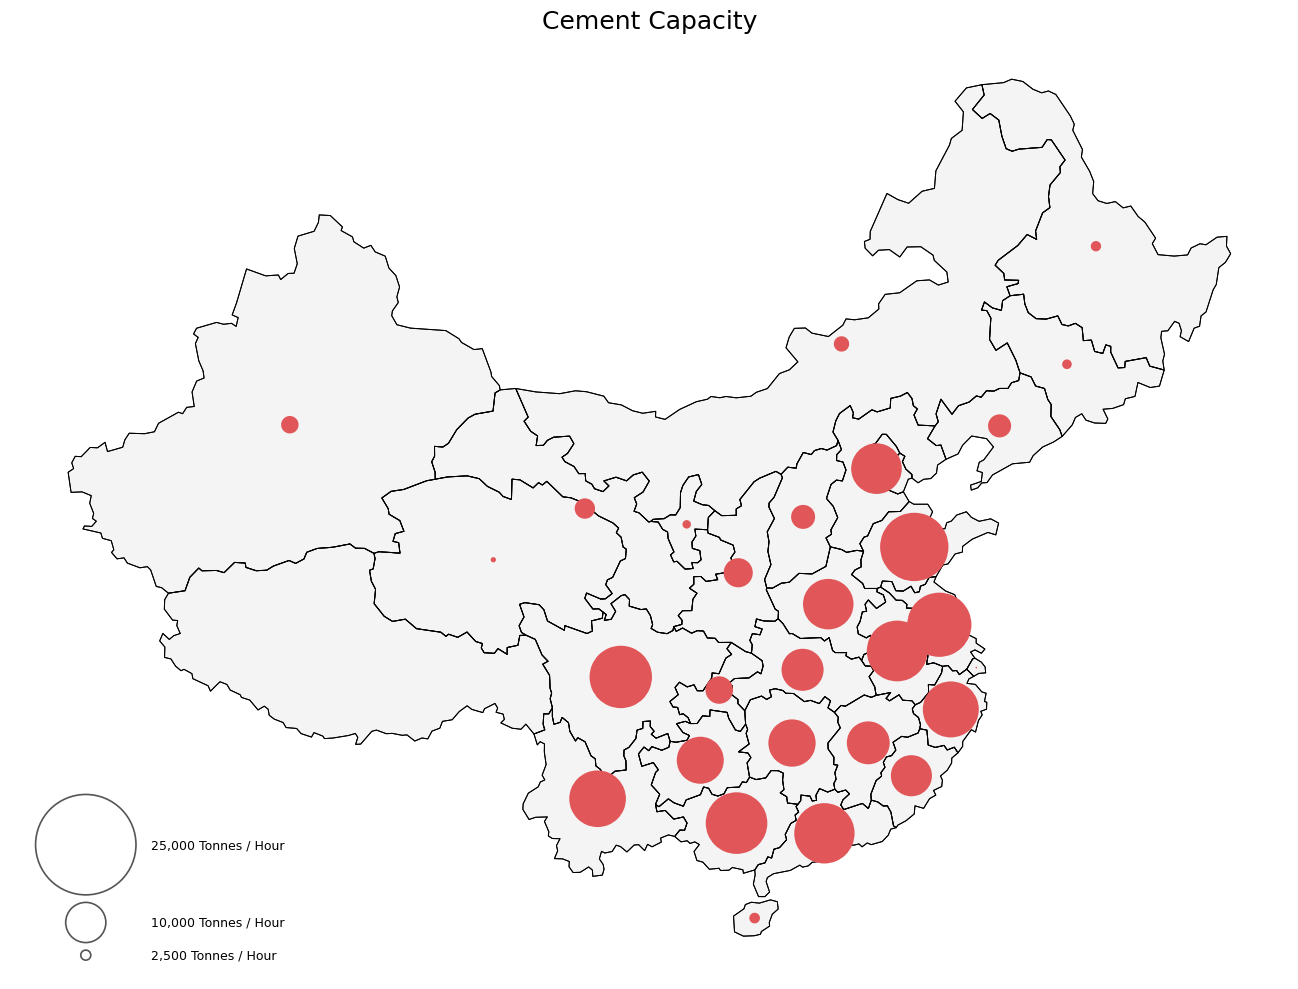

In [111]:
plot_province_pies(gdf, cement_df['noemissionscap'],
                   colors=custom_color_map,
                   pie_scale=2.5,
                   title="Cement Capacity",
                   legend_sizes=[2_500, 10_000, 25_000],
                   capacity_unit="Tonnes / Hour")

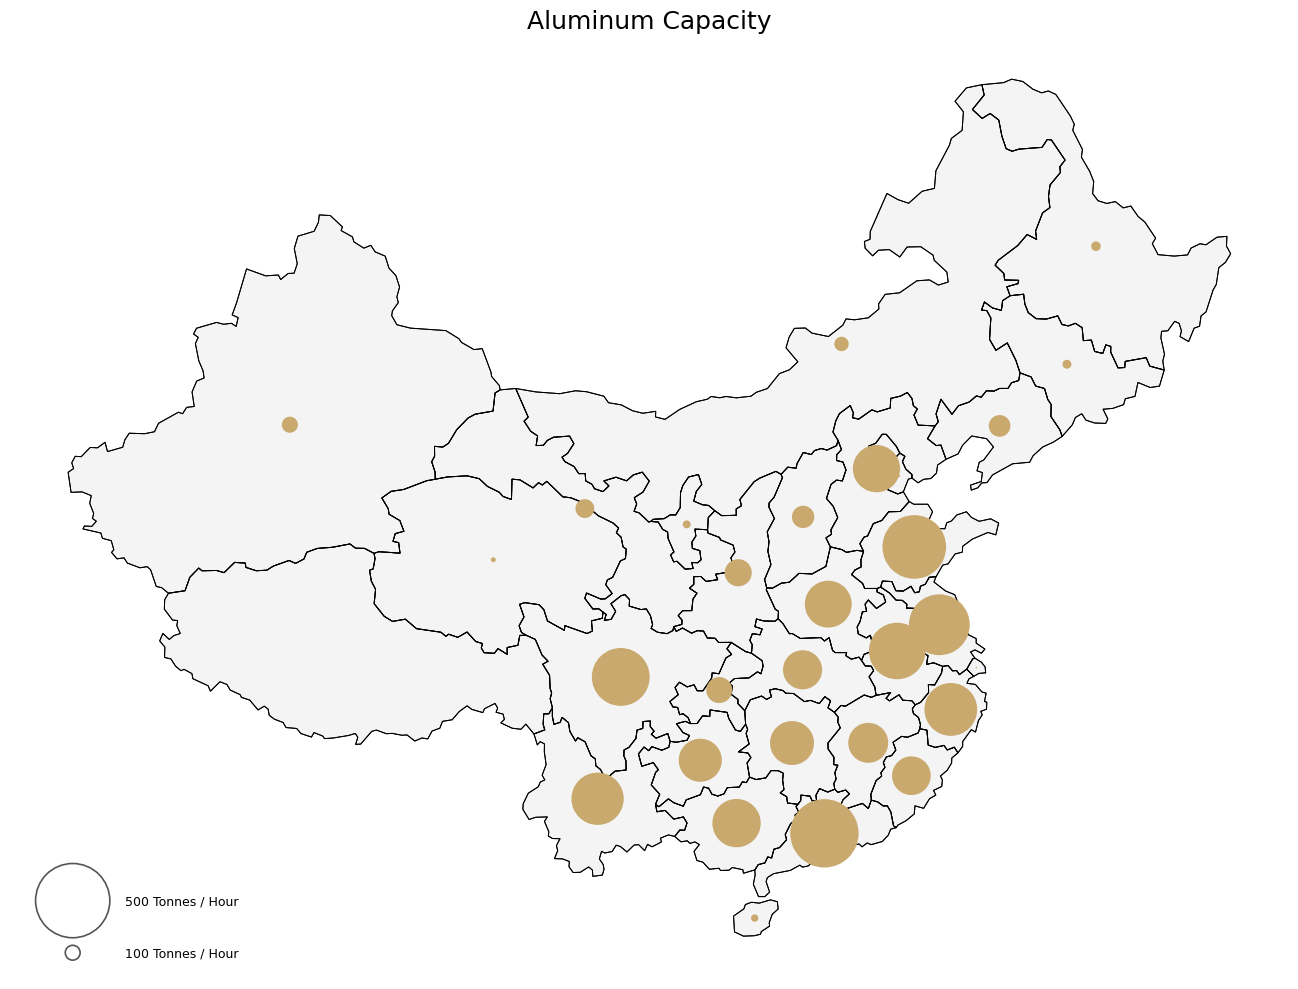

In [112]:
plot_province_pies(gdf, aluminum_df['noemissionscap'],
                   colors=custom_color_map,
                   pie_scale=2.5,
                   title="Aluminum Capacity",
                   legend_sizes=[100, 500],
                   capacity_unit="Tonnes / Hour")

# Steel Material Transportation Flows

In [35]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

def plot_transport_flows(
    flows_df,
    transport_prefix,         # e.g. "steelscrap_transport", "dri_transport", "crudesteel_transport"
    gdf_input,
    province_col="NAME_1",
    title="Transport Flows",
    color="#1f77b4",
    figsize=(12, 10),
    flow_threshold=100,       # net flows below this are not drawn
    max_shaft_width=150_000,  # metres (EPSG:3857) for the largest flow
    min_shaft_width=20_000,
    head_width_ratio=2.5,     # arrowhead width = ratio × shaft width
    legend_sizes=None,        # e.g. [5_000, 50_000, 200_000]
    unit_label="Tonnes",
):
    """
    Plot net inter-province transport flows as solid filled arrows on a China map.
    Net flow = flow(A→B) − flow(B→A); only the dominant direction is drawn.
    Arrow style matches PowerPoint block arrows (filled polygon, shaft + head).
    """
    gdf = gdf_input.copy()

    # --- Collect matching columns ---
    col_pat = re.compile(
        rf"^{re.escape(transport_prefix)}_Region\d+\w+_to_Region\d+\w+_transmission_edge$"
    )
    transport_cols = [c for c in flows_df.columns if col_pat.match(c)]
    if not transport_cols:
        print(f"No columns found for prefix: {transport_prefix}")
        return

    flow_sums = flows_df[transport_cols].sum()

    # --- Build directed dict ---
    edge_pat = re.compile(
        rf"^{re.escape(transport_prefix)}_Region\d+(\w+)_to_Region\d+(\w+)_transmission_edge$"
    )
    directed = {}
    for col, val in flow_sums.items():
        m = edge_pat.match(col)
        if m:
            directed[(m.group(1), m.group(2))] = val

    # --- Net flows per unordered pair ---
    pairs_seen = set()
    net_flows = []
    for (src, dst), fwd in directed.items():
        if (dst, src) in pairs_seen or (src, dst) in pairs_seen:
            continue
        pairs_seen.add((src, dst))
        rev = directed.get((dst, src), 0.0)
        net = fwd - rev
        if abs(net) > flow_threshold:
            net_flows.append((src, dst, net) if net > 0 else (dst, src, -net))

    if not net_flows:
        print("No net flows above threshold.")
        return

    # --- Project + centroids ---
    gdf_proj = gdf.to_crs(epsg=3857)
    gdf_proj["centroid"] = gdf_proj.geometry.centroid
    centroid_map = dict(zip(
        gdf_proj[province_col],
        zip(gdf_proj.centroid.x, gdf_proj.centroid.y)
    ))

    max_flow = max(f for _, _, f in net_flows)

    def shaft_w(flow):
        frac = (flow / max_flow) ** 0.5
        return min_shaft_width + frac * (max_shaft_width - min_shaft_width)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    gdf_proj.plot(ax=ax, color="#F4F4F4", edgecolor="#888888", linewidth=0.6, zorder=0)

    for src, dst, flow in sorted(net_flows, key=lambda x: x[2]):   # small first → large on top
        if src not in centroid_map or dst not in centroid_map:
            continue
        x0, y0 = centroid_map[src]
        x1, y1 = centroid_map[dst]
        dx, dy  = x1 - x0, y1 - y0
        dist    = np.hypot(dx, dy)

        sw = shaft_w(flow)
        hw = sw * head_width_ratio
        hl = min(dist * 0.32, hw * 1.4)    # head_length: capped at 32% of distance
        alpha = 0.45 + 0.55 * (flow / max_flow)

        ax.arrow(
            x0, y0, dx, dy,
            width=sw,
            head_width=hw,
            head_length=hl,
            length_includes_head=True,
            fc=color,
            ec="white",
            linewidth=0.5,
            alpha=alpha,
            zorder=5,
        )

    plt.title(title, fontsize=16, pad=12)

    # --- Manual size legend drawn directly on axes (like plot_province_pies) ---
    if legend_sizes is None:
        legend_sizes = [max_flow * f for f in [0.1, 0.5, 1.0]]

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    pw = xlim[1] - xlim[0]
    ph = ylim[1] - ylim[0]

    arrow_len  = pw * 0.09
    lx         = xlim[0] + pw * 0.02
    ly         = ylim[0] + ph * 0.03
    max_legend_sw = shaft_w(max(legend_sizes))

    for size in sorted(legend_sizes):
        sw = shaft_w(size)
        hw = sw * head_width_ratio
        hl = min(arrow_len * 0.32, hw * 1.4)

        ax.arrow(
            lx, ly, arrow_len, 0,
            width=sw, head_width=hw, head_length=hl,
            length_includes_head=True,
            fc=color, ec="white", linewidth=0.5, alpha=0.85,
            zorder=10,
        )
        ax.text(
            lx + arrow_len + pw * 0.01, ly,
            f"{size:,.0f} {unit_label}",
            va="center", ha="left", fontsize=9, zorder=11,
        )
        ly += max_legend_sw * 3.2

    # Legend title
    ax.text(
        lx, ly + max_legend_sw * 0.5,
        "Annual Net Flow",
        fontsize=9, fontweight="bold", zorder=11,
    )

    plt.tight_layout()
    plt.show()


In [36]:
gdf = gpd.read_file("../gadm36_CHN_1.json")

rename_map = {
    "Nei Mongol": "Innermongolia",
    "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia",
    "Xinjiang Uygur": "Xinjiang",
}
gdf["NAME_1"] = gdf["NAME_1"].replace(rename_map)

flows_80 = flow_dfs["80pct"]

# --- Total materials transported (sum over time, all edges) ---
cement_total = flows_80[[c for c in flows_80.columns if "cement_transport" in c and "transmission_edge" in c]].sum().sum()
scrap_total  = flows_80[[c for c in flows_80.columns if "steelscrap_transport" in c and "transmission_edge" in c]].sum().sum()
dri_total    = flows_80[[c for c in flows_80.columns if "dri_transport" in c and "transmission_edge" in c]].sum().sum()
crude_total  = flows_80[[c for c in flows_80.columns if "crudesteel_transport" in c and "transmission_edge" in c]].sum().sum()
co2_total    = flows_80[[c for c in flows_80.columns if "CO2_Pipeline_transmission_edge" in c]].sum().sum()

print(f"80pct total cement transported:      {cement_total:,.0f} Tonnes")
print(f"80pct total scrap steel transported: {scrap_total:,.0f} Tonnes")
print(f"80pct total DRI transported:         {dri_total:,.0f} Tonnes")
print(f"80pct total crude steel transported: {crude_total:,.0f} Tonnes")
print(f"80pct total CO2 transported:         {co2_total:,.0f} Tonnes")

KeyError: '90pct'

In [37]:
plot_transport_flows(
    flows_df=flows_80,
    transport_prefix="cement_transport",
    gdf_input=gdf,
    title="Cement Transport — 80% Emissions Reduction",
    color="#e15759",
    figsize=(12, 10),
    legend_sizes=[5_000, 50_000, 200_000],
    unit_label="Tonnes"
)

NameError: name 'flows_90' is not defined

In [38]:
plot_transport_flows(
    flows_df=flows_80,
    transport_prefix="steelscrap_transport",
    gdf_input=gdf,
    title="Scrap Steel Transport — 80% Emissions Reduction",
    color="#38a938",
    figsize=(12, 10),
    legend_sizes=[5_000, 50_000, 200_000],
    unit_label="Tonnes",
    flow_threshold=5000
)

NameError: name 'flows_90' is not defined

In [39]:
plot_transport_flows(
    flows_df=flows_80,
    transport_prefix="dri_transport",
    gdf_input=gdf,
    title="DRI Transport — 80% Emissions Reduction",
    color="#9467bd",
    figsize=(12, 10),
    legend_sizes=[5_000, 50_000, 200_000],
    unit_label="Tonnes",
    flow_threshold=5000
)


NameError: name 'flows_90' is not defined

In [40]:
plot_transport_flows(
    flows_df=flows_80,
    transport_prefix="crudesteel_transport",
    gdf_input=gdf,
    title="Crude Steel Transport — 80% Emissions Reduction",
    color="#1f77b4",
    figsize=(12, 10),
    legend_sizes=[5_000, 50_000, 200_000],
    unit_label="Tonnes",
    flow_threshold=5000
)


NameError: name 'flows_90' is not defined

In [41]:
from pyproj import Transformer

# Basin centroids (lon, lat) from usgs_source/basin_centroids_shapefile.csv
BASIN_COORDS = {
    "Songliao":        (124.2489, 45.5424),
    "TurpanHami":      (91.8474,  42.7741),
    "Subei":           (120.2968, 33.2802),
    "BohaiOnshore":    (117.027,  38.1531),
    "Qaidam":          (94.0675,  37.4565),
    "Nanxiang":        (112.3891, 32.6284),
    "Sanjiang":        (132.0,    47.0   ),
    "Hailar":          (118.5403, 48.9011),
    "Jianghan":        (112.9206, 30.4742),
    "Tarim":           (82.2819,  39.3991),
    "Ordos":           (108.7178, 37.5548),
    "YingenEjina":     (101.5,    41.5   ),
    "Hehuai":          (115.0,    34.0   ),
    "Qinshui":         (112.4531, 36.7143),
    "Erlian":          (115.3402, 44.1892),
    "Junggar":         (87.0998,  44.9779),
    "SichuanBasin":    (105.9742, 30.357 ),
    "BohaiOffshore":   (119.7405, 39.0081),
    "NorthYellowSea":  (123.3029, 38.3492),
    "SouthYellowSea":  (123.0614, 35.6424),
    "EastChinaSea":    (124.815,  29.2425),
    "PearlRiverMouth": (114.5827, 20.6148),
    "BeibugGulf":      (109.1529, 20.3578),
    "Qiongdongnan":    (110.6,    17.9   ),
}

def plot_co2_transport_flows(
    flows_df,
    gdf_input,
    province_col="NAME_1",
    title="CO2 Transport Flows",
    color="#4a5568",
    figsize=(13, 11),
    flow_threshold=100,
    max_shaft_width=80_000,
    min_shaft_width=8_000,
    head_width_ratio=2.5,
    legend_sizes=None,
    unit_label="Tonnes",
):
    """
    Plot CO2 pipeline flows from province centroids to CO2 storage basin locations.
    Column pattern: Region{N}{Province}_to_{Basin}_CO2_Pipeline_transmission_edge
    Basin coordinates sourced from usgs_source/basin_centroids_shapefile.csv.
    """
    transformer = Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)
    basin_xy = {name: transformer.transform(lon, lat) for name, (lon, lat) in BASIN_COORDS.items()}

    col_pat = re.compile(r"^Region\d+(\w+)_to_(\w+)_CO2_Pipeline_transmission_edge$")
    flows = {}
    for col in flows_df.columns:
        m = col_pat.match(col)
        if m:
            province, basin = m.group(1), m.group(2)
            val = flows_df[col].sum()
            if val > flow_threshold:
                flows[(province, basin)] = flows.get((province, basin), 0) + val

    if not flows:
        print("No CO2 transport flows found above threshold.")
        return

    gdf = gdf_input.copy().to_crs(epsg=3857)
    gdf["centroid"] = gdf.geometry.centroid
    centroid_map = dict(zip(gdf[province_col], zip(gdf.centroid.x, gdf.centroid.y)))

    max_flow = max(flows.values())

    def shaft_w(flow):
        frac = (flow / max_flow) ** 0.5
        return min_shaft_width + frac * (max_shaft_width - min_shaft_width)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    gdf.plot(ax=ax, color="#F4F4F4", edgecolor="#888888", linewidth=0.6, zorder=0)

    for (province, basin), flow in sorted(flows.items(), key=lambda x: x[1]):
        if province not in centroid_map or basin not in basin_xy:
            continue
        x0, y0 = centroid_map[province]
        x1, y1 = basin_xy[basin]
        dx, dy  = x1 - x0, y1 - y0
        dist    = np.hypot(dx, dy)
        sw = shaft_w(flow)
        hw = sw * head_width_ratio
        hl = min(dist * 0.30, hw * 1.4)
        alpha = 0.30 + 0.70 * (flow / max_flow)
        ax.arrow(x0, y0, dx, dy,
                 width=sw, head_width=hw, head_length=hl,
                 length_includes_head=True,
                 fc=color, ec="white", linewidth=0.4,
                 alpha=alpha, zorder=5)

    # Mark basin locations
    for name, (bx, by) in basin_xy.items():
        ax.plot(bx, by, "v", color="#e15759", markersize=6, zorder=10, clip_on=False)
        ax.text(bx, by + 50_000, name, fontsize=6, ha="center", va="bottom", zorder=11, clip_on=False)

    plt.title(title, fontsize=16, pad=12)

    if legend_sizes is None:
        legend_sizes = [max_flow * f for f in [0.1, 0.5, 1.0]]

    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    pw = xlim[1] - xlim[0]; ph = ylim[1] - ylim[0]
    arrow_len = pw * 0.09
    lx = xlim[0] + pw * 0.02
    ly = ylim[0] + ph * 0.03
    max_legend_sw = shaft_w(max(legend_sizes))

    for size in sorted(legend_sizes):
        sw = shaft_w(size)
        hw = sw * head_width_ratio
        hl = min(arrow_len * 0.32, hw * 1.4)
        ax.arrow(lx, ly, arrow_len, 0,
                 width=sw, head_width=hw, head_length=hl,
                 length_includes_head=True,
                 fc=color, ec="white", linewidth=0.5, alpha=0.85, zorder=10)
        ax.text(lx + arrow_len + pw * 0.01, ly,
                f"{size:,.0f} {unit_label}", va="center", ha="left", fontsize=9, zorder=11)
        ly += max_legend_sw * 3.2

    ax.text(lx, ly + max_legend_sw * 0.5, "Annual Flow",
            fontsize=9, fontweight="bold", zorder=11)

    plt.tight_layout()
    plt.show()


plot_co2_transport_flows(
    flows_df=flows_80,
    gdf_input=gdf,
    title="CO2 Pipeline Transport — 80% Emissions Reduction",
    color="#4a5568",
    figsize=(13, 11),
    legend_sizes=[500_000, 2_000_000, 5_000_000],
    unit_label="Tonnes",
    flow_threshold=100000,
)

NameError: name 'flows_90' is not defined